# 04 - Results and Report Figures

Aggregates all pushed experiment runs, computes the Profit Gain Index per
seed, runs the hypothesis tests, and renders every report figure.
Works locally or on Colab after `git pull` (all inputs are the small run
outputs shared through git, no training needed here).

In [1]:
import json
import subprocess
import sys

import pandas as pd

from airbnb_marl.utils.paths import repo_root, results_dir

for script in ('scripts/evaluate.py', 'scripts/make_figures.py'):
    print('=== running', script, '===')
    subprocess.run([sys.executable, str(repo_root() / script)], check=True)

=== running scripts/evaluate.py ===
[17:18:19] wrote deltas.csv (100 runs)
[17:18:19] wrote summary.json
{
  "per_experiment": {
    "E1": {
      "n_runs": 20,
      "mean_delta": -0.7674598896610725,
      "std_delta": 0.07939255507236254,
      "mean_price_ratio": 1.1097104266958424,
      "mean_profit": 0.36434881947483594
    },
    "E2": {
      "n_runs": 20,
      "mean_delta": -1.2308017319421505,
      "std_delta": 0.168548847106781,
      "mean_price_ratio": 1.844082089715536,
      "mean_profit": 0.7453148728665209
    },
    "E3": {
      "n_runs": 20,
      "mean_delta": 0.2654215846426481,
      "std_delta": 0.13346472936943335,
      "mean_price_ratio": 1.60968989059081,
      "mean_profit": 0.4411044776805252
    },
    "E4": {
      "n_runs": 20,
      "mean_delta": -1.2637222655848042,
      "std_delta": 0.21828789440126703,
      "mean_price_ratio": 1.0748924288840265,
      "mean_profit": 0.32747048807439827
    },
    "E5": {
      "n_runs": 20,
      "mean_delta":

## Profit Gain Index per experiment

In [2]:
deltas = pd.read_csv(results_dir() / 'evaluation' / 'deltas.csv')
summary = json.loads((results_dir() / 'evaluation' / 'summary.json').read_text())

display(pd.DataFrame(summary['per_experiment']).T.round(4))
print('hypothesis tests:')
print(json.dumps(summary['hypothesis_tests'], indent=2))

,n_runs,mean_delta,std_delta,mean_price_ratio,mean_profit
E1,20.0,-0.7675,0.0794,1.1097,0.3643
E2,20.0,-1.2308,0.1685,1.8441,0.7453
E3,20.0,0.2654,0.1335,1.6097,0.4411
E4,20.0,-1.2637,0.2183,1.0749,0.3275
E5,20.0,-1.0048,0.0791,1.1220,0.3467


hypothesis tests:
{
  "H1_dqn_collusion": {
    "mean_delta": -0.7674598896610725,
    "std_delta": 0.07939255507236254,
    "n_runs": 20,
    "threshold": 0.15,
    "t_stat": -51.67997624063787,
    "p_value": 1.0,
    "rejected_h0": false
  },
  "H2_tql_gt_dqn": {
    "mean_a": -1.2637222655848042,
    "mean_b": -0.7674598896610725,
    "u_stat": 10.0,
    "p_value": 0.9999998718527068,
    "significant": false
  },
  "H2_dqn_gt_ppo": {
    "mean_a": -0.7674598896610725,
    "mean_b": 0.2654215846426481,
    "u_stat": 0.0,
    "p_value": 0.9999999707854003,
    "significant": false
  },
  "H3_n2_gt_n4": {
    "mean_a": -0.7674598896610725,
    "mean_b": -1.2308017319421505,
    "u_stat": 399.0,
    "p_value": 3.9490168333373314e-08,
    "significant": true
  }
}


## Bounds and baselines context

In [3]:
for path in sorted((results_dir() / 'experiments').glob('bounds_n*.json')):
    bounds = json.loads(path.read_text())
    print(path.name)
    print('  nash profit', round(bounds['nash_profit_per_agent_step'], 4),
          'ratios', bounds['nash_price_ratios'])
    print('  monopoly profit', round(bounds['monopoly_profit_per_agent_step'], 4),
          'ratios', bounds['monopoly_price_ratios'])
    for name, r in bounds.get('baselines', {}).items():
        print(f"  baseline {name}: profit {r['profit_per_agent_step']:.4f} "
              f"ratio {r['mean_price_ratio']:.3f}")

bounds_n2.json
  nash profit 0.4214 ratios [1.075, 1.55]
  monopoly profit 0.4957 ratios [2.5, 1.125]
  baseline random: profit 0.2976 ratio 0.937
  baseline median_seeker: profit 0.2642 ratio 0.802
  baseline anchor: profit 0.3153 ratio 1.000
bounds_n4.json
  nash profit 0.8829 ratios [2.5, 2.5, 2.5, 2.5]
  monopoly profit 0.9948 ratios [1.375, 2.5, 2.5, 2.5]
  baseline random: profit 0.3252 ratio 0.898
  baseline median_seeker: profit 0.3952 ratio 1.025
  baseline anchor: profit 0.4100 ratio 1.033


## Figures

delta_violins.png


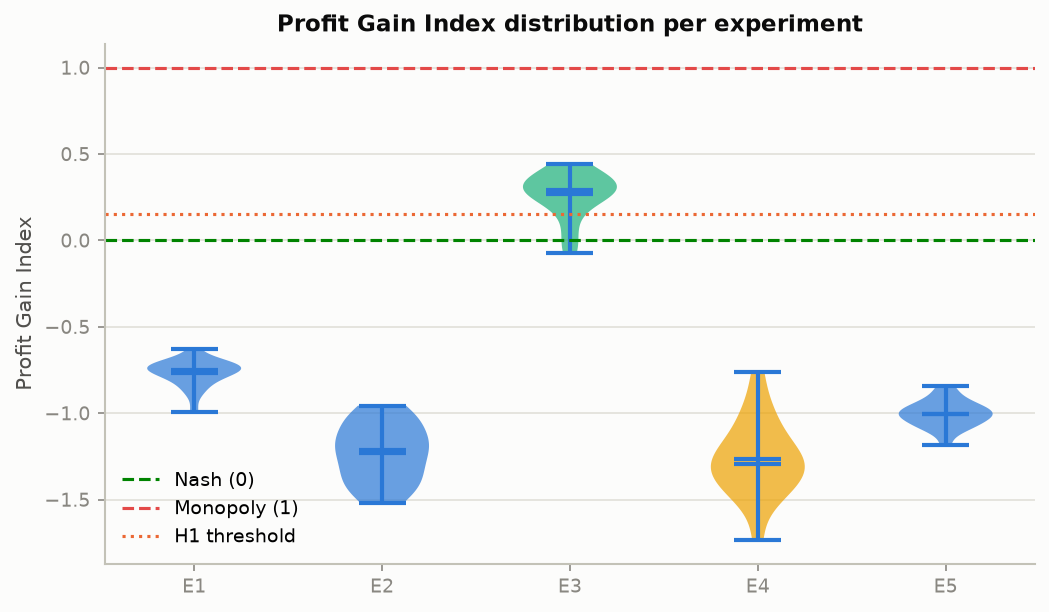

joint_actions_E1.png


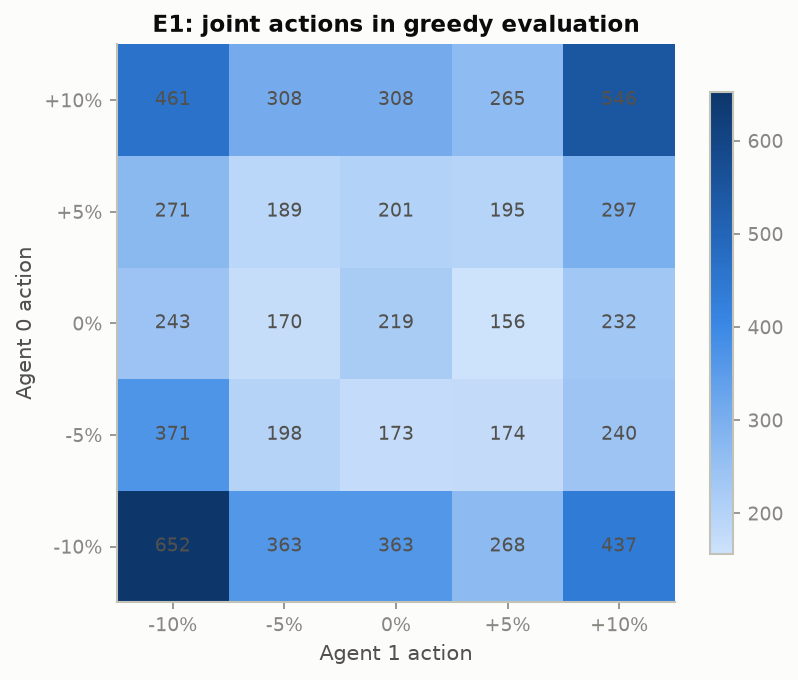

learning_curve_E1.png


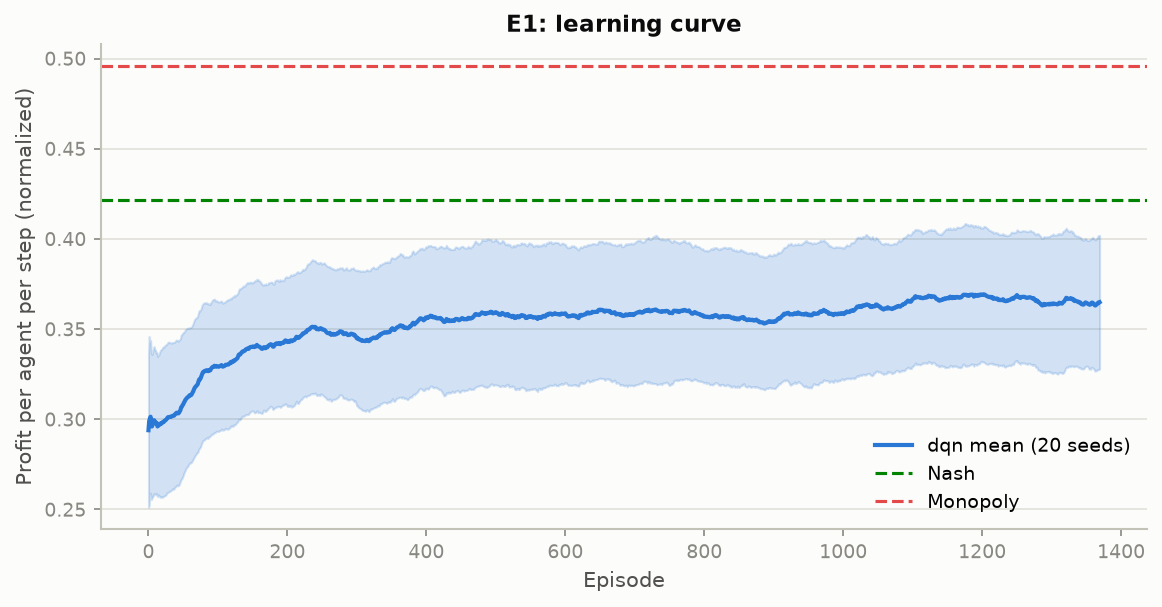

learning_curve_E2.png


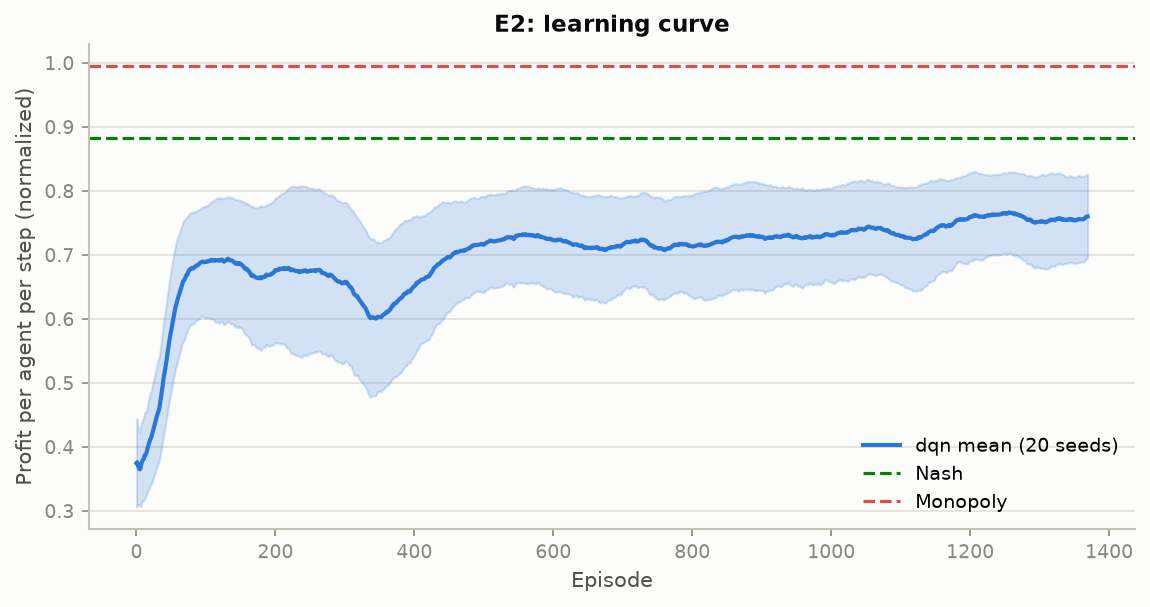

learning_curve_E3.png


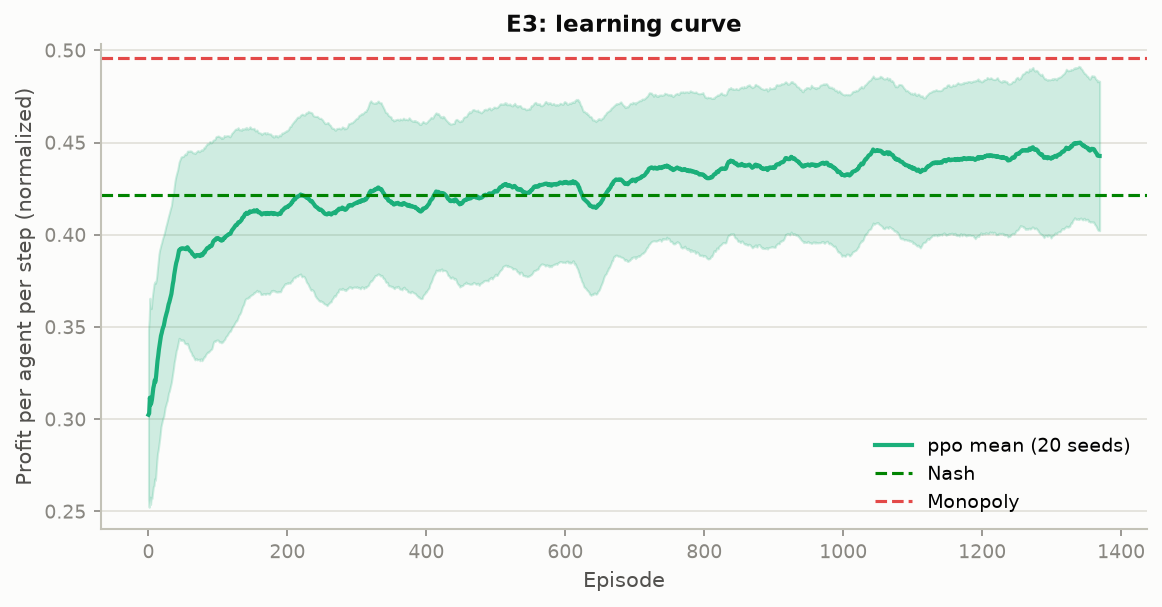

learning_curve_E4.png


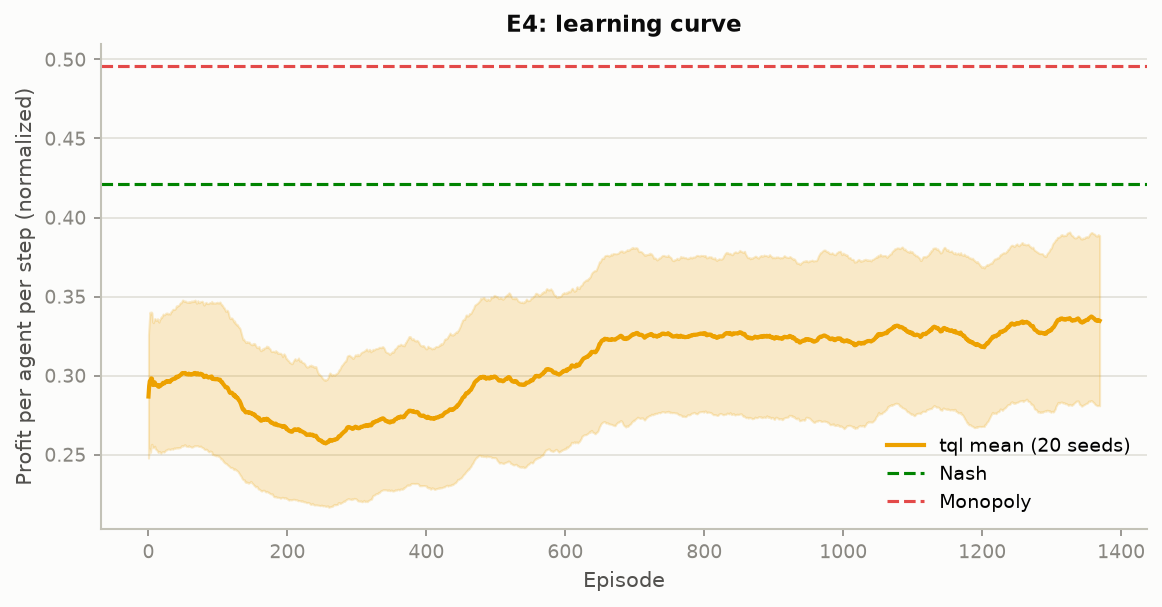

learning_curve_E5.png


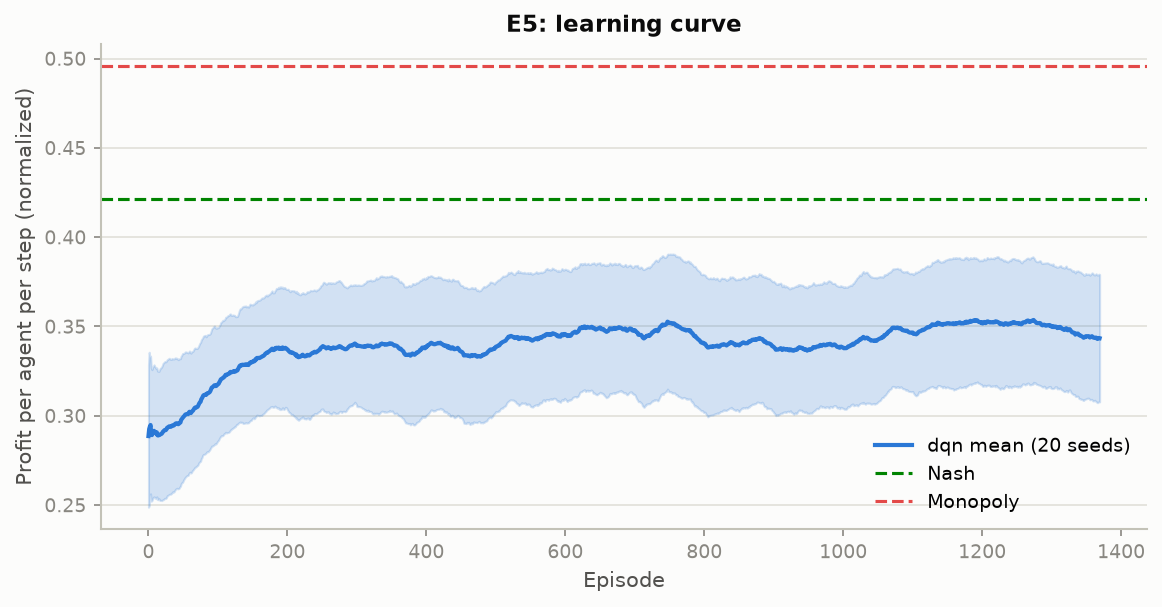

price_trajectory_E1.png


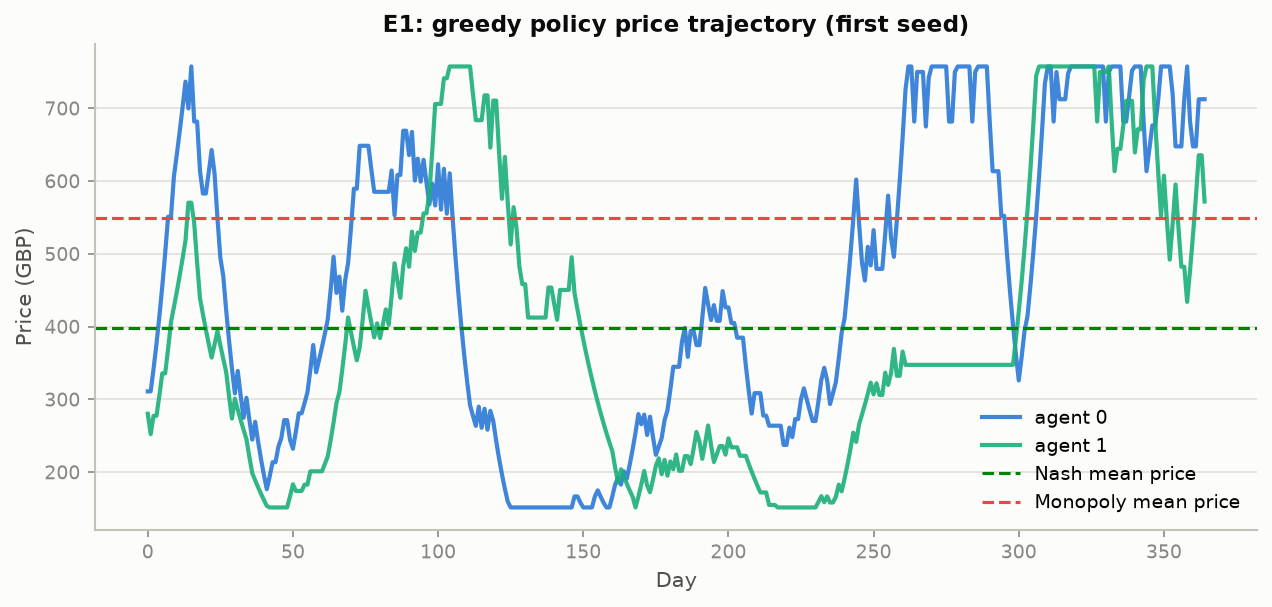

price_trajectory_E2.png


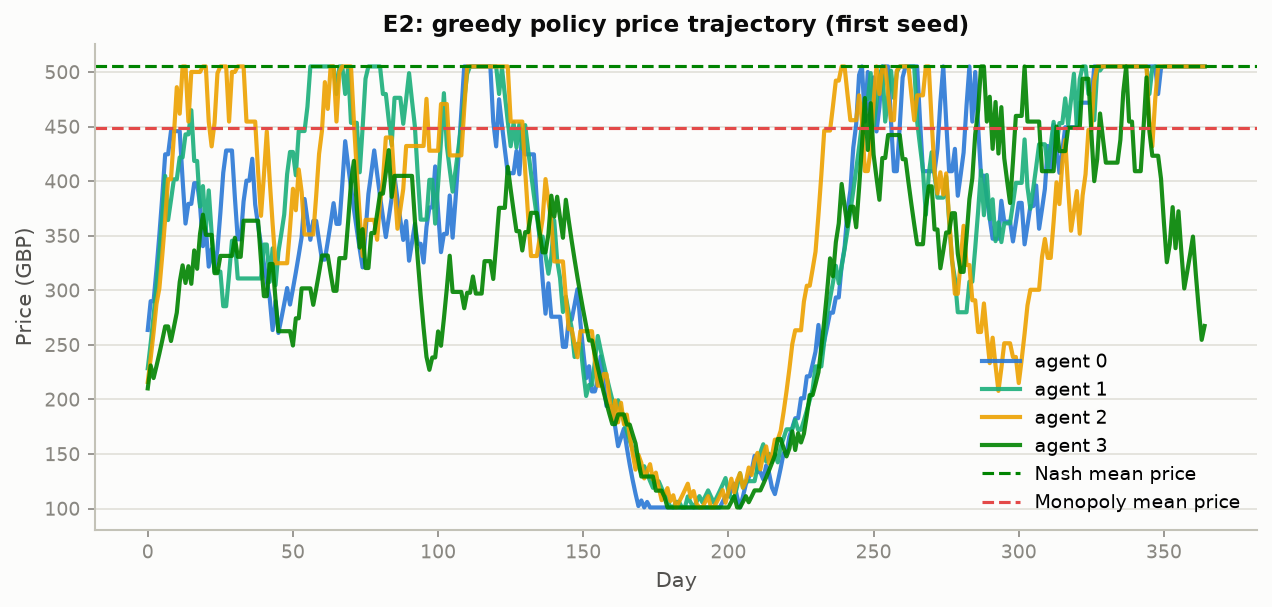

price_trajectory_E3.png


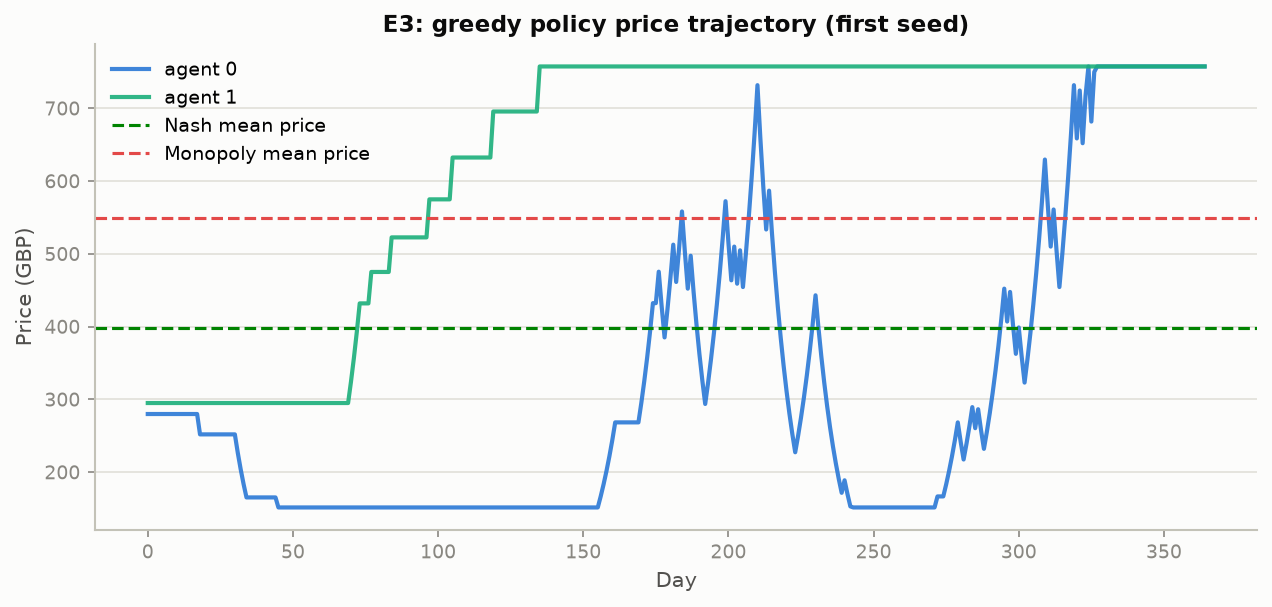

price_trajectory_E4.png


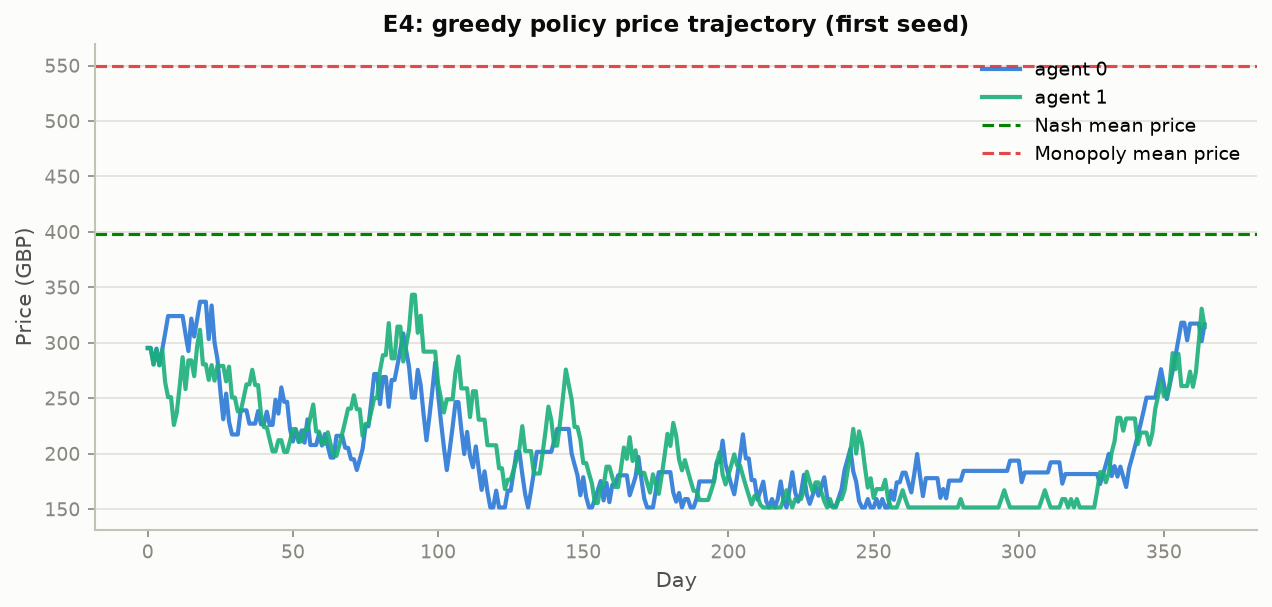

price_trajectory_E5.png


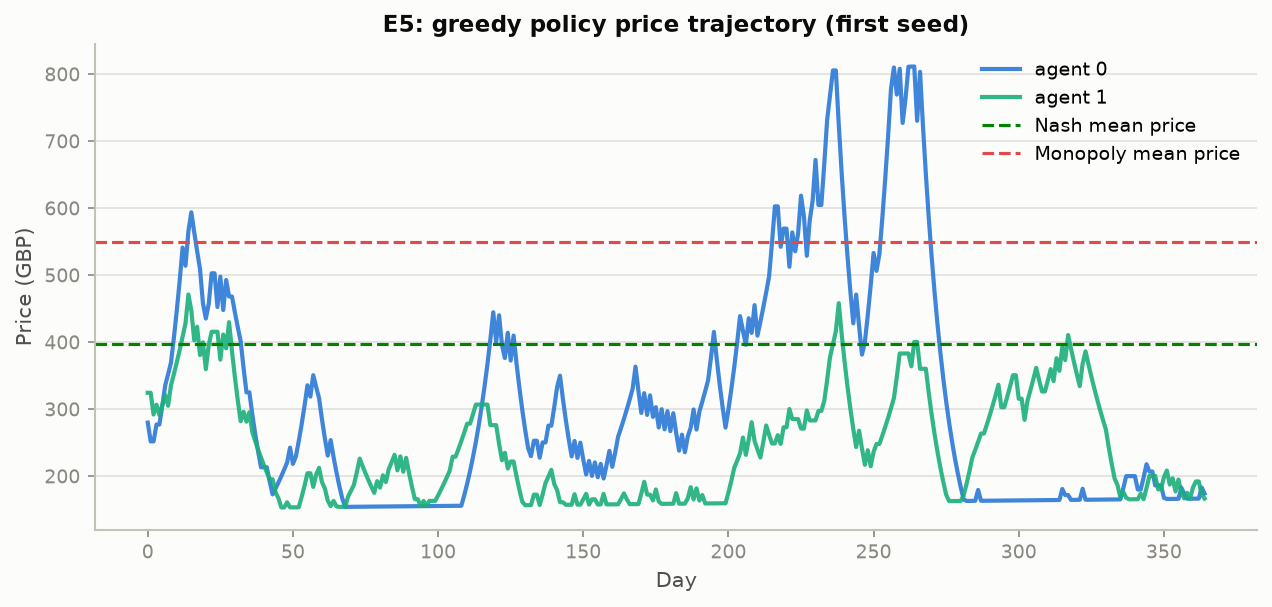

In [4]:
from IPython.display import Image, display

for png in sorted((results_dir() / 'figures').glob('*.png')):
    print(png.name)
    display(Image(filename=str(png)))

## Price recommendation demo

The same artifacts double as the backend of a commercial pricing tool
(PriceLabs, AirDNA MarketMinder): the demand model answers "what price
maximizes my expected revenue", and a trained agent replayed greedily is
a full dynamic price calendar.

The static sweep below needs the processed data (run
`scripts/download_data.py` and `scripts/preprocess.py` first); the policy
calendar works directly from the run outputs shared through git.
Recommendations are averaged over the year and inherit the demand model's
limits: the price signal is cross sectional with a structural elasticity
correction, so they are most trustworthy near the market median. One of
the two listings below shows a clean interior optimum; the other's
modeled demand is flat enough that the optimizer runs to the price cap,
the same limitation discussed for the four agent market in the report.

listing 4909320 (listed 311 GBP): recommended 758 GBP (2.50x median), booking prob 0.169, expected 128 GBP/night
listing 1553150358117819622 (listed 295 GBP): recommended 439 GBP (1.45x median), booking prob 0.285, expected 125 GBP/night


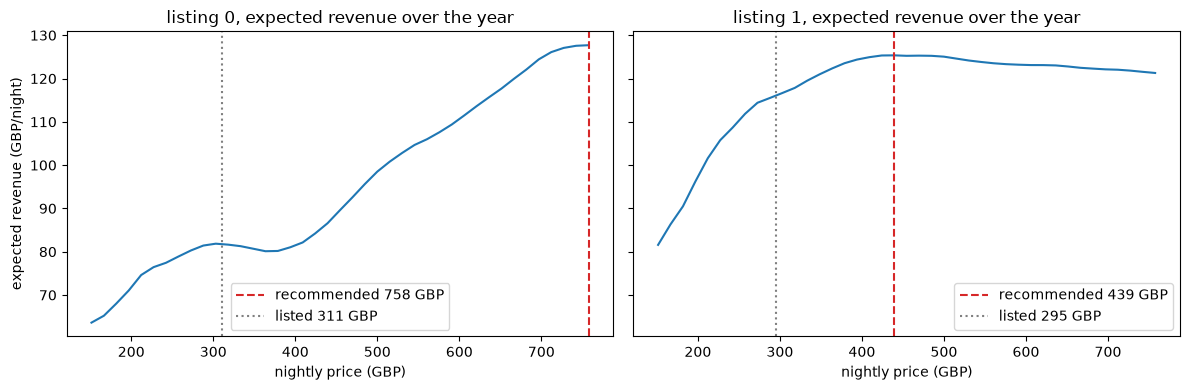

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from airbnb_marl.config import load_config
from airbnb_marl.demand.interface import DemandModel
from airbnb_marl.env.market import select_market
from airbnb_marl.env.market_env import PricingMarketEnv
from airbnb_marl.utils.paths import processed_dir, repo_root

listings_path = processed_dir() / 'listings_clean.parquet'
if not listings_path.exists():
    print('processed data missing, run scripts/download_data.py and scripts/preprocess.py first')
else:
    cfg = load_config(repo_root() / 'configs/experiments/E1_dqn_n2.yaml')
    env_cfg = load_config(repo_root() / 'configs/env.yaml', overrides=cfg.get('env') or {})
    market = select_market(pd.read_parquet(listings_path), n_agents=cfg['n_agents'],
                           neighbourhood=cfg['market']['neighbourhood'],
                           room_type=cfg['market']['room_type'])
    env = PricingMarketEnv(DemandModel.load(results_dir() / 'demand'), market, env_cfg)

    rivals = env.base_prices.copy()   # competitors hold their listed prices
    days = np.linspace(0, env.episode_length - 1, 26).astype(int)
    grid = np.linspace(env_cfg['price_min_ratio'], env_cfg['price_max_ratio'], 41) * env.cluster_median

    fig, axes = plt.subplots(1, env.n, figsize=(6 * env.n, 4), sharey=True)
    for L, ax in zip(range(env.n), np.atleast_1d(axes)):
        probs = np.asarray([
            np.mean([env.demand_probs(np.where(np.arange(env.n) == L, c, rivals), int(d))[L]
                     for d in days])
            for c in grid
        ])
        revenue = grid * probs
        best = int(np.argmax(revenue))
        print(f"listing {market['listing_id'].iloc[L]} (listed {rivals[L]:.0f} GBP): "
              f"recommended {grid[best]:.0f} GBP ({grid[best] / env.cluster_median:.2f}x median), "
              f"booking prob {probs[best]:.3f}, expected {revenue[best]:.0f} GBP/night")
        ax.plot(grid, revenue, color='tab:blue')
        ax.axvline(grid[best], color='tab:red', ls='--', label=f'recommended {grid[best]:.0f} GBP')
        ax.axvline(rivals[L], color='gray', ls=':', label=f'listed {rivals[L]:.0f} GBP')
        ax.set_xlabel('nightly price (GBP)')
        ax.set_title(f'listing {L}, expected revenue over the year')
        ax.legend()
    np.atleast_1d(axes)[0].set_ylabel('expected revenue (GBP/night)')
    plt.tight_layout()
    plt.show()

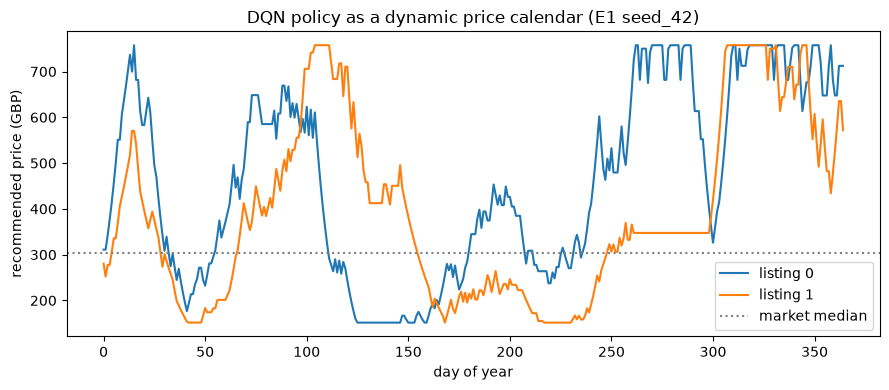

season revenue per listing, normalized by base price: [129.3, 181.2]


In [6]:
# a trained agent replayed greedily is a dynamic pricing calendar for the
# whole year, read straight from the pushed eval traces
trace_path = sorted((results_dir() / 'experiments' / 'E1').glob('seed_*/eval_trace.npz'))[0]
trace = np.load(trace_path)
prices, rewards = trace['prices'], trace['rewards']

fig, ax = plt.subplots(figsize=(9, 4))
for j in range(prices.shape[1]):
    ax.plot(prices[:, j], label=f'listing {j}')
ax.axhline(float(trace['cluster_median']), color='gray', ls=':', label='market median')
ax.set_xlabel('day of year')
ax.set_ylabel('recommended price (GBP)')
ax.set_title(f'DQN policy as a dynamic price calendar (E1 {trace_path.parent.name})')
ax.legend()
plt.tight_layout()
plt.show()

print('season revenue per listing, normalized by base price:',
      rewards.sum(axis=0).round(1).tolist())